# TrOCR Fine-tuning — Doctor's Handwritten Prescription BD Dataset

This notebook fine-tunes the TrOCR model for recognizing handwritten medicine names from cropped prescription images. The workflow includes loading the official training, validation, and testing splits, applying light data augmentation to improve generalization, fine-tuning TrOCR using CER as the main validation metric, and evaluating the final model using Character Error Rate (CER), Word Error Rate (WER), and Exact Match Accuracy.

The notebook also compares the baseline TrOCR model with the fine-tuned version, saves prediction results to a CSV file, and generates plots for training loss, validation performance, and final model comparison.


## 1 · Install

In [1]:
!pip install -q transformers datasets evaluate accelerate jiwer kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-c

## 2 · Imports & Config

In [2]:
import json, os, random, warnings, shutil, math, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset
from transformers import (
    TrOCRProcessor, VisionEncoderDecoderModel,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, TrainerCallback, set_seed,
)
import evaluate
import kagglehub


MODEL_ID   = 'microsoft/trocr-base-handwritten'
OUTPUT_DIR = Path('/kaggle/working/trocr-prescription')

RESET_OUTPUT_DIR = True
if RESET_OUTPUT_DIR and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED       = 42
MAX_LEN    = 32     
GEN_MAX_TOKENS = MAX_LEN
GEN_BEAMS  = 4    

BATCH_SIZE = 8    
EPOCHS     = 10    
LR         = 2e-5  
WARMUP_RATIO = 0.05


WEIGHT_DECAY            = 0.03
LABEL_SMOOTHING         = 0.05
EARLY_STOPPING_PATIENCE = 3 

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_ID}')
print(f'MAX_LEN / GEN_MAX_TOKENS: {MAX_LEN}')


Device : cuda
Model  : microsoft/trocr-base-handwritten
MAX_LEN / GEN_MAX_TOKENS: 32


## 3 · Download Dataset & Build Pairs

In [3]:
# Download (uses cache if already present)
dataset_root = Path(kagglehub.dataset_download(
    'mamun1113/doctors-handwritten-prescription-bd-dataset'
))
print('Dataset root:', dataset_root)

# Show structure
for p in sorted(dataset_root.rglob('*')):
    depth = len(p.relative_to(dataset_root).parts)
    if depth <= 3:
        icon = '📁' if p.is_dir() else '📄'
        print('  ' * (depth - 1) + icon + ' ' + p.name)

Dataset root: /kaggle/input/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset
📁 Doctor’s Handwritten Prescription BD dataset
  📁 Testing
    📄 testing_labels.csv
    📁 testing_words
  📁 Training
    📄 training_labels.csv
    📁 training_words
  📁 Validation
    📄 validation_labels.csv
    📁 validation_words


In [4]:
def find_img_dir(csv_path: Path) -> Path:
    """Return the sibling image folder that most likely contains word images."""
    candidates = []
    for d in sorted(csv_path.parent.iterdir()):
        if d.is_dir() and any(k in d.name.lower() for k in ('word', 'image', 'img')):
            candidates.append(d)
    return candidates[0] if candidates else csv_path.parent


def load_pairs(csv_path: Path, img_dir: Path):
    df = pd.read_csv(csv_path)
    print(f'  {csv_path.name}: columns = {list(df.columns)}')


    fn_col = next(
        (c for c in df.columns if any(k in c.lower()
         for k in ('file', 'image', 'img', 'name', 'word', 'filename'))),
        df.columns[0],
    )
    lbl_col = next(
        (c for c in df.columns if any(k in c.lower()
         for k in ('label', 'text', 'transcript', 'gt', 'medicine', 'word'))
         and c != fn_col),
        df.columns[1],
    )
    print(f'  → filename col: "{fn_col}"  |  label col: "{lbl_col}"')

    pairs, missing = [], 0
    for _, row in df.iterrows():
        fname = str(row[fn_col]).strip()
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            fname += '.png'

        img_path = img_dir / fname
        if not img_path.exists():
            img_path = img_dir / Path(fname).name

        label = str(row[lbl_col]).strip()
        if img_path.exists() and label and label.lower() != 'nan':
            pairs.append((img_path, label))
        else:
            missing += 1

    if missing:
        print(f'  ⚠ {missing} rows skipped (missing image or empty label)')
    return pairs

all_csvs  = sorted(dataset_root.rglob('*.csv'))
train_csv = next((c for c in all_csvs if 'train' in c.name.lower()), None)
val_csv   = next((c for c in all_csvs if any(k in c.name.lower() for k in ('val', 'valid'))), None)
test_csv  = next((c for c in all_csvs if 'test' in c.name.lower()), None)

assert train_csv and val_csv and test_csv, f'Could not find train/val/test CSVs in: {all_csvs}'

train_pairs = load_pairs(train_csv, find_img_dir(train_csv))
val_pairs   = load_pairs(val_csv,   find_img_dir(val_csv))
test_pairs  = load_pairs(test_csv,  find_img_dir(test_csv))


random.Random(SEED).shuffle(train_pairs)

print(f'\n✅  Official splits loaded — Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')
assert train_pairs, 'train_pairs is empty — check CSV columns and image paths above'
assert val_pairs,   'val_pairs is empty — check CSV columns and image paths above'
assert test_pairs,  'test_pairs is empty — check CSV columns and image paths above'


  training_labels.csv: columns = ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']
  → filename col: "IMAGE"  |  label col: "MEDICINE_NAME"
  validation_labels.csv: columns = ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']
  → filename col: "IMAGE"  |  label col: "MEDICINE_NAME"
  testing_labels.csv: columns = ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']
  → filename col: "IMAGE"  |  label col: "MEDICINE_NAME"

✅  Official splits loaded — Train: 3120 | Val: 780 | Test: 780


## 4 · Visualise Samples

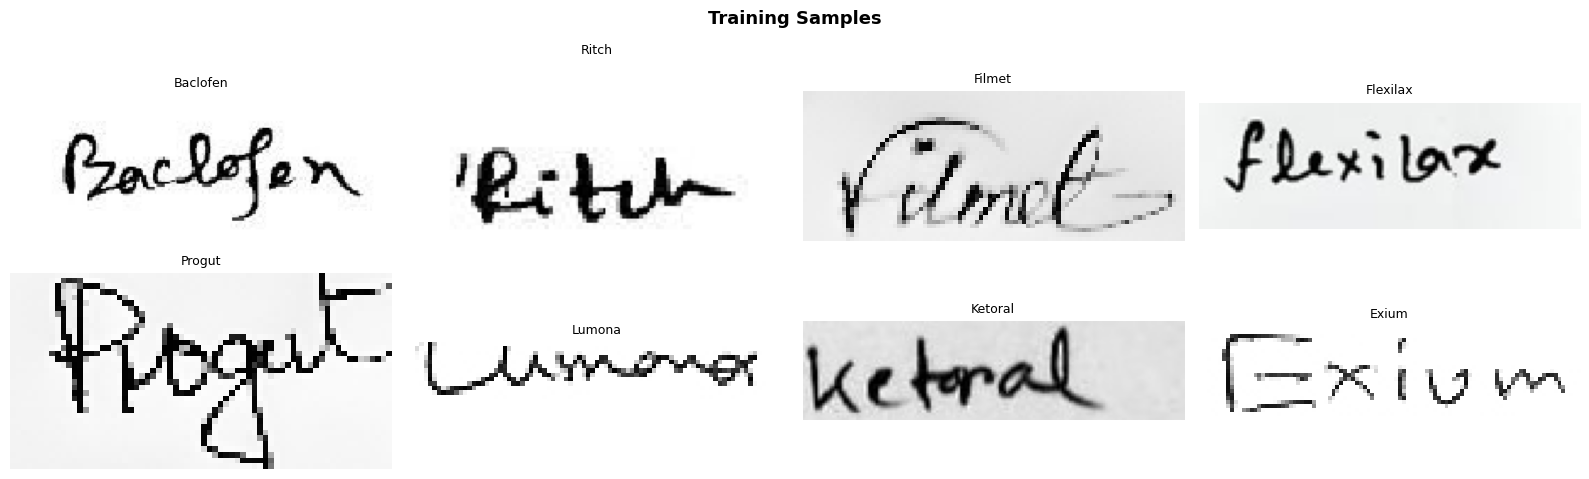

In [5]:
samples = random.sample(train_pairs, min(8, len(train_pairs)))
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for ax, (img_path, label) in zip(axes.flat, samples):
    ax.imshow(Image.open(img_path).convert('RGB'))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples.png', dpi=120)
plt.show()

## 5 · Load Processor & Model

In [6]:
processor = TrOCRProcessor.from_pretrained(MODEL_ID)
token_lengths = [
    len(processor.tokenizer(str(label), add_special_tokens=True).input_ids)
    for _, label in train_pairs
]
if token_lengths:
    print('Token length percentiles [90, 95, 99]:', np.percentile(token_lengths, [90, 95, 99]).round(1).tolist())
    print('Maximum train label token length:', max(token_lengths))
    print('Current MAX_LEN:', MAX_LEN)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)


model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

model.generation_config.max_length   = MAX_LEN
model.generation_config.num_beams    = GEN_BEAMS
model.generation_config.eos_token_id = processor.tokenizer.sep_token_id
model.generation_config.pad_token_id = processor.tokenizer.pad_token_id

model = model.to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Model on {DEVICE} — {total/1e6:.1f}M parameters')


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model on cuda — 333.9M parameters


## 6 · PyTorch Dataset

In [7]:
def augment_handwriting_image(image: Image.Image) -> Image.Image:
    """Light training-only augmentation for handwritten word images."""
    if random.random() < 0.80:
        image = image.rotate(random.uniform(-3, 3), expand=False, fillcolor=(255, 255, 255))
    if random.random() < 0.50:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.85, 1.15))
    if random.random() < 0.50:
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.20))
    if random.random() < 0.20:
        image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.6)))

    return image


class PrescriptionDataset(Dataset):
    def __init__(self, pairs, train=False):
        self.pairs = pairs
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, label = self.pairs[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            raise RuntimeError(f'Could not open image: {img_path}') from e

        if self.train:
            image = augment_handwriting_image(image)

        pixel_values = processor(images=image, return_tensors='pt').pixel_values.squeeze(0)

        token_ids = processor.tokenizer(
            text=label,
            padding='max_length',
            max_length=MAX_LEN,
            truncation=True,
        ).input_ids

        labels = [
            t if t != processor.tokenizer.pad_token_id else -100
            for t in token_ids
        ]
        return {'pixel_values': pixel_values, 'labels': torch.tensor(labels, dtype=torch.long)}


train_ds = PrescriptionDataset(train_pairs, train=True)
val_ds   = PrescriptionDataset(val_pairs,   train=False)
test_ds  = PrescriptionDataset(test_pairs,  train=False)
print(f'Datasets ready — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')


Datasets ready — train: 3120, val: 780, test: 780


## 7 · Metrics

In [8]:
cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

def normalize_text(s: str) -> str:
    """
    Normalize model outputs and labels before OCR metrics:
    lowercase, trim extra spaces, and remove punctuation.
    """
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s


def exact_match_score(predictions, references) -> float:
    preds = [normalize_text(x) for x in predictions]
    refs  = [normalize_text(x) for x in references]
    if not refs:
        return 0.0
    return sum(p == r for p, r in zip(preds, refs)) / len(refs)


def compute_metrics(pred):
    label_ids = pred.label_ids.copy()
    pred_ids  = pred.predictions

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_strs  = processor.batch_decode(pred_ids,  skip_special_tokens=True)
    label_strs = processor.batch_decode(label_ids, skip_special_tokens=True)

    pred_norms  = [normalize_text(x) for x in pred_strs]
    label_norms = [normalize_text(x) for x in label_strs]

    return {
        'cer': round(cer_metric.compute(predictions=pred_norms, references=label_norms), 4),
        'wer': round(wer_metric.compute(predictions=pred_norms, references=label_norms), 4),
        'exact_match': round(exact_match_score(pred_norms, label_norms), 4),
    }


def run_evaluation(eval_model, pairs, desc='Evaluating'):
    """Full inference loop — returns normalized CER/WER/Exact Match plus raw predictions/refs."""
    eval_model.eval()
    preds_raw, refs_raw = [], []

    for img_path, ref in tqdm(pairs, desc=desc):
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'⚠ Skipping unreadable image: {img_path} ({e})')
            continue

        inputs = processor(images=image, return_tensors='pt').to(DEVICE)

        with torch.no_grad():
            ids = eval_model.generate(
                **inputs,
                max_new_tokens=GEN_MAX_TOKENS,
                num_beams=GEN_BEAMS,
            )

        preds_raw.append(processor.batch_decode(ids, skip_special_tokens=True)[0].strip())
        refs_raw.append(ref)

    preds_norm = [normalize_text(x) for x in preds_raw]
    refs_norm  = [normalize_text(x) for x in refs_raw]

    cer = cer_metric.compute(predictions=preds_norm, references=refs_norm)
    wer = wer_metric.compute(predictions=preds_norm, references=refs_norm)
    em  = exact_match_score(preds_norm, refs_norm)

    return cer, wer, em, preds_raw, refs_raw

print('Metrics ready: CER, WER, and Exact Match Accuracy.')


Metrics ready: CER, WER, and Exact Match Accuracy.


## 8 · Baseline Evaluation (before fine-tuning)

In [9]:
print('Running baseline inference on the official test set...')
base_cer, base_wer, base_em, base_preds, base_refs = run_evaluation(
    model, test_pairs, desc='Baseline'
)
print(f'\nBaseline CER         : {base_cer:.4f}  ({base_cer*100:.2f}%)')
print(f'Baseline WER         : {base_wer:.4f}  ({base_wer*100:.2f}%)')
print(f'Baseline Exact Match : {base_em:.4f}  ({base_em*100:.2f}%)')

print('\nSample predictions:')
for ref, pred in list(zip(base_refs, base_preds))[:8]:
    print(f'  GT  : {ref}')
    print(f'  Pred: {pred}')
    print()


Running baseline inference on the official test set...


Baseline:   0%|          | 0/780 [00:00<?, ?it/s]


Baseline CER         : 0.4022  (40.22%)
Baseline WER         : 0.9051  (90.51%)
Baseline Exact Match : 0.2295  (22.95%)

Sample predictions:
  GT  : Aceta
  Pred: Acute .

  GT  : Aceta
  Pred: aceta

  GT  : Aceta
  Pred: . Aceta

  GT  : Aceta
  Pred: Atlanta .

  GT  : Aceta
  Pred: Aeeto

  GT  : Aceta
  Pred: acort .

  GT  : Aceta
  Pred: Austin .

  GT  : Aceta
  Pred: Atlanta .



## 9 · Fine-tune

In [10]:
class VisionSeq2SeqDataCollator:
    def __init__(self, model):
        self.model = model

    def __call__(self, features):
        pixel_values = torch.stack([f['pixel_values'] for f in features])
        labels = torch.stack([f['labels'] for f in features])

        batch = {
            'pixel_values': pixel_values,
            'labels': labels,
            'decoder_input_ids': self.model.prepare_decoder_input_ids_from_labels(labels=labels),
        }
        return batch


data_collator = VisionSeq2SeqDataCollator(model)

for old_dir in list(OUTPUT_DIR.glob('checkpoint-*')) + list(OUTPUT_DIR.glob('tmp-*')):
    if old_dir.is_dir():
        shutil.rmtree(old_dir)
        print(f'Removed old training folder: {old_dir}')

old_best = OUTPUT_DIR / 'best_model'
if old_best.exists():
    shutil.rmtree(old_best)
    print(f'Removed old exported model folder: {old_best}')

num_gpus = max(1, torch.cuda.device_count())
steps_per_epoch = math.ceil(len(train_ds) / (BATCH_SIZE * num_gpus))
total_training_steps = steps_per_epoch * EPOCHS
WARMUP_STEPS = max(1, int(total_training_steps * WARMUP_RATIO))

print(f"Warmup steps: {WARMUP_STEPS} / {total_training_steps} total training steps")

training_args_kwargs = dict(
    output_dir                  = str(OUTPUT_DIR),
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,

    weight_decay                = WEIGHT_DECAY,
    label_smoothing_factor      = LABEL_SMOOTHING,

    warmup_steps                = WARMUP_STEPS,
    lr_scheduler_type           = 'cosine',
    fp16                        = (DEVICE == 'cuda'),
    predict_with_generate       = True,
    generation_max_length       = MAX_LEN,
    generation_num_beams        = GEN_BEAMS,

    save_strategy               = 'epoch',
    save_total_limit            = 1,

    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_cer',
    greater_is_better           = False,

    remove_unused_columns       = False,

    logging_steps               = 20,
    report_to                   = 'none',
    dataloader_num_workers      = 2,
    seed                        = SEED,
)

import inspect
training_arg_params = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters

if 'eval_strategy' in training_arg_params:
    training_args_kwargs['eval_strategy'] = 'epoch'
else:
    training_args_kwargs['evaluation_strategy'] = 'epoch'


if 'save_safetensors' in training_arg_params:
    training_args_kwargs['save_safetensors'] = False

if 'save_only_model' in training_arg_params:
    training_args_kwargs['save_only_model'] = True

args = Seq2SeqTrainingArguments(**training_args_kwargs)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0,
        ),
    ],
)

train_result = trainer.train()


trainer.save_model(str(OUTPUT_DIR / 'best_model'))
processor.save_pretrained(str(OUTPUT_DIR / 'best_model'))

print('Fine-tuning complete. Best model saved.')
print(f'Best checkpoint : {trainer.state.best_model_checkpoint}')
print(f'Best eval_cer   : {trainer.state.best_metric:.6f}')
print(f"Train loss      : {train_result.metrics['train_loss']:.4f}")


os.system('df -h /kaggle/working')


Warmup steps: 97 / 1950 total training steps


Epoch,Training Loss,Validation Loss,Cer,Wer,Exact Match
1,1.806225,0.894695,0.028700,0.050600,0.948700
2,1.638512,0.816015,0.014000,0.020300,0.979500
3,1.557277,0.793059,0.010200,0.012700,0.987200
4,1.539831,0.785355,0.008100,0.011400,0.988500
5,1.516566,0.776487,0.008100,0.010100,0.989700
6,1.515876,0.771917,0.007500,0.010100,0.989700
7,1.504471,0.773163,0.008700,0.011400,0.988500
8,1.502301,0.770936,0.008900,0.011400,0.988500
9,1.500798,0.770897,0.008700,0.011400,0.988500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete. Best model saved.
Best checkpoint : /kaggle/working/trocr-prescription/checkpoint-1170
Best eval_cer   : 0.007500
Train loss      : 1.8324
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  2.5G   18G  13% /kaggle/working


0

## 10 · Post-fine-tuning Evaluation

In [11]:
trainer.save_model(str(OUTPUT_DIR / 'best_model'))
processor.save_pretrained(str(OUTPUT_DIR / 'best_model'))

print(f"Best model folder: {OUTPUT_DIR / 'best_model'}")
print(f"Best checkpoint  : {trainer.state.best_model_checkpoint}")
print(f"Best eval_cer    : {trainer.state.best_metric:.6f}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model folder: /kaggle/working/trocr-prescription/best_model
Best checkpoint  : /kaggle/working/trocr-prescription/checkpoint-1170
Best eval_cer    : 0.007500


In [12]:
for entry in trainer.state.log_history:
    if 'eval_loss' in entry:
        print(
            f"Epoch {entry['epoch']:.0f} | "
            f"val_loss: {entry['eval_loss']:.4f} | "
            f"CER: {entry.get('eval_cer', float('nan')):.4f} | "
            f"WER: {entry.get('eval_wer', float('nan')):.4f} | "
            f"Exact Match: {entry.get('eval_exact_match', float('nan')):.4f}"
        )


Epoch 1 | val_loss: 0.8947 | CER: 0.0287 | WER: 0.0506 | Exact Match: 0.9487
Epoch 2 | val_loss: 0.8160 | CER: 0.0140 | WER: 0.0203 | Exact Match: 0.9795
Epoch 3 | val_loss: 0.7931 | CER: 0.0102 | WER: 0.0127 | Exact Match: 0.9872
Epoch 4 | val_loss: 0.7854 | CER: 0.0081 | WER: 0.0114 | Exact Match: 0.9885
Epoch 5 | val_loss: 0.7765 | CER: 0.0081 | WER: 0.0101 | Exact Match: 0.9897
Epoch 6 | val_loss: 0.7719 | CER: 0.0075 | WER: 0.0101 | Exact Match: 0.9897
Epoch 7 | val_loss: 0.7732 | CER: 0.0087 | WER: 0.0114 | Exact Match: 0.9885
Epoch 8 | val_loss: 0.7709 | CER: 0.0089 | WER: 0.0114 | Exact Match: 0.9885
Epoch 9 | val_loss: 0.7709 | CER: 0.0087 | WER: 0.0114 | Exact Match: 0.9885


In [13]:
ft_model = VisionEncoderDecoderModel.from_pretrained(
    str(OUTPUT_DIR / 'best_model')
).to(DEVICE)

ft_model.generation_config.max_length   = MAX_LEN
ft_model.generation_config.num_beams    = GEN_BEAMS
ft_model.generation_config.eos_token_id = processor.tokenizer.sep_token_id
ft_model.generation_config.pad_token_id = processor.tokenizer.pad_token_id

print('Running fine-tuned inference on the official test set...')
ft_cer, ft_wer, ft_em, ft_preds, ft_refs = run_evaluation(
    ft_model, test_pairs, desc='Fine-tuned'
)
print(f'\nFine-tuned CER         : {ft_cer:.4f}  ({ft_cer*100:.2f}%)')
print(f'Fine-tuned WER         : {ft_wer:.4f}  ({ft_wer*100:.2f}%)')
print(f'Fine-tuned Exact Match : {ft_em:.4f}  ({ft_em*100:.2f}%)')

print('\nSample predictions:')
for ref, pred in list(zip(ft_refs, ft_preds))[:8]:
    print(f'  GT  : {ref}')
    print(f'  Pred: {pred}')
    print()


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Running fine-tuned inference on the official test set...


Fine-tuned:   0%|          | 0/780 [00:00<?, ?it/s]


Fine-tuned CER         : 0.0185  (1.85%)
Fine-tuned WER         : 0.0241  (2.41%)
Fine-tuned Exact Match : 0.9756  (97.56%)

Sample predictions:
  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta

  GT  : Aceta
  Pred: Aceta



## 12 · Results Comparison


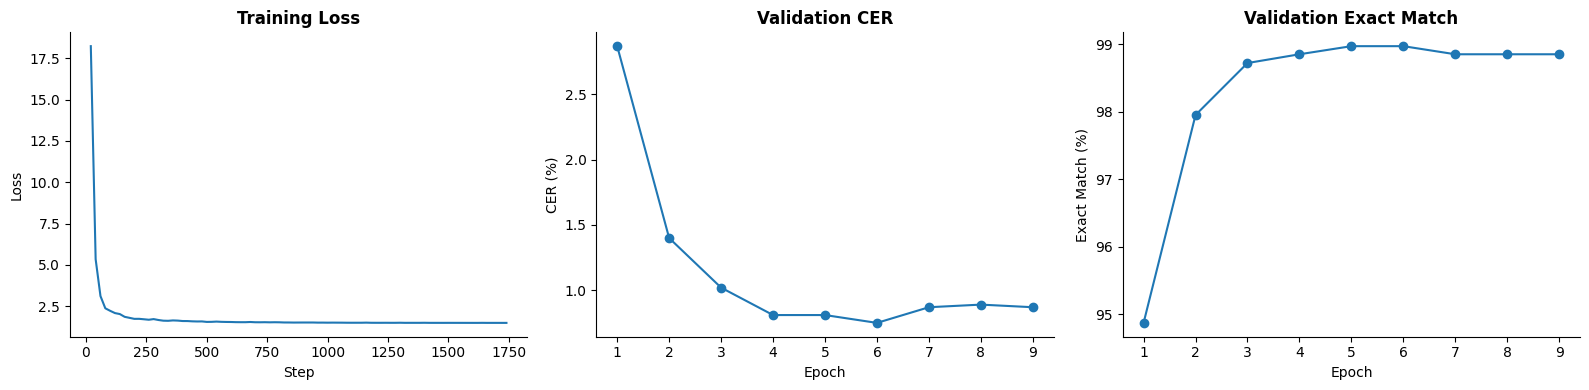

In [14]:
logs = trainer.state.log_history
train_steps  = [(e['step'], e['loss']) for e in logs if 'loss' in e and 'eval_loss' not in e]
eval_epochs  = [(e['epoch'], e['eval_cer'], e.get('eval_wer'), e.get('eval_exact_match'))
                for e in logs if 'eval_cer' in e]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
if train_steps:
    steps, losses = zip(*train_steps)
    axes[0].plot(steps, losses)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
    axes[0].spines[['top','right']].set_visible(False)
if eval_epochs:
    ep, cers, wers, exacts = zip(*eval_epochs)
    axes[1].plot(ep, [c*100 for c in cers], marker='o')
    axes[1].set_title('Validation CER', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CER (%)')
    axes[1].spines[['top','right']].set_visible(False)

    valid_exact = [x for x in exacts if x is not None]
    if valid_exact:
        axes[2].plot(ep, [x*100 if x is not None else np.nan for x in exacts], marker='o')
        axes[2].set_title('Validation Exact Match', fontweight='bold')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Exact Match (%)')
        axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()


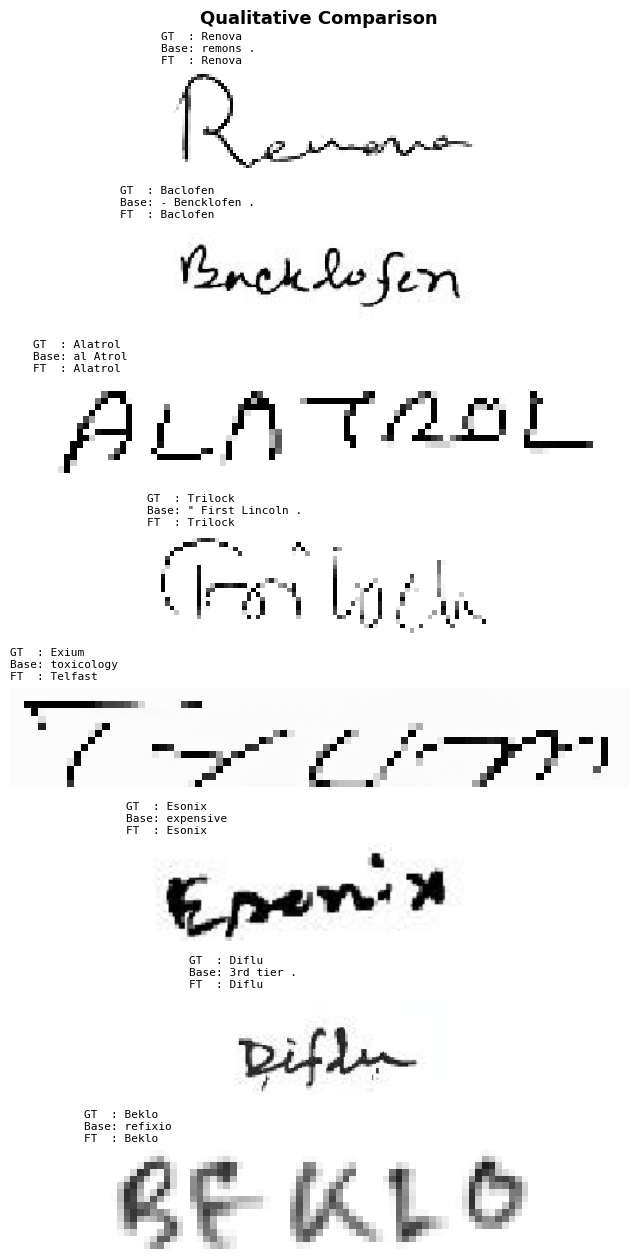

In [15]:
n = min(8, len(test_pairs))
idxs = random.sample(range(len(test_pairs)), n)
fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.6))
if n == 1:
    axes = [axes]

for ax, i in zip(axes, idxs):
    img = Image.open(test_pairs[i][0]).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'GT  : {test_pairs[i][1]}\n'
        f'Base: {base_preds[i]}\n'
        f'FT  : {ft_preds[i]}',
        fontsize=8, loc='left', fontfamily='monospace'
    )

plt.suptitle('Qualitative Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'qualitative.png', dpi=120, bbox_inches='tight')
plt.show()


## 13 · Save Results


In [18]:
def relative_improvement_lower_is_better(before, after):
    """
    Used for CER and WER.
    Positive value means error decreased.
    """
    if before == 0:
        return 0.0
    return ((before - after) / before) * 100


def relative_improvement_higher_is_better(before, after):
    """
    Used for Exact Match.
    Positive value means accuracy increased.
    """
    if before == 0:
        return 0.0
    return ((after - before) / before) * 100


cer_imp = relative_improvement_lower_is_better(base_cer, ft_cer)
wer_imp = relative_improvement_lower_is_better(base_wer, ft_wer)
em_imp  = relative_improvement_higher_is_better(base_em, ft_em)

print(f"CER improvement: {cer_imp:.2f}%")
print(f"WER improvement: {wer_imp:.2f}%")
print(f"Exact Match improvement: {em_imp:.2f}%")

CER improvement: 95.40%
WER improvement: 97.34%
Exact Match improvement: 325.14%


In [20]:
prediction_csv_path = OUTPUT_DIR / "test_predictions.csv"

test_df = pd.DataFrame({
    "image": [str(p[0]) for p in test_pairs],
    "ground_truth": ft_refs,
    "baseline_prediction": base_preds,
    "fine_tuned_prediction": ft_preds,
})

test_df["ground_truth_norm"] = test_df["ground_truth"].apply(normalize_text)
test_df["baseline_prediction_norm"] = test_df["baseline_prediction"].apply(normalize_text)
test_df["fine_tuned_prediction_norm"] = test_df["fine_tuned_prediction"].apply(normalize_text)

test_df["baseline_correct"] = (
    test_df["ground_truth_norm"] == test_df["baseline_prediction_norm"]
)

test_df["fine_tuned_correct"] = (
    test_df["ground_truth_norm"] == test_df["fine_tuned_prediction_norm"]
)

test_df.to_csv(prediction_csv_path, index=False)

print(f"Saved prediction CSV to: {prediction_csv_path}")
test_df.head()

Saved prediction CSV to: /kaggle/working/trocr-prescription/test_predictions.csv


,image,ground_truth,baseline_prediction,fine_tuned_prediction,ground_truth_norm,baseline_prediction_norm,fine_tuned_prediction_norm,baseline_correct,fine_tuned_correct
0,/kaggle/input/datasets/mamun1113/doctors-handw...,Aceta,Acute .,Aceta,aceta,acute,aceta,False,True
1,/kaggle/input/datasets/mamun1113/doctors-handw...,Aceta,aceta,Aceta,aceta,aceta,aceta,True,True
2,/kaggle/input/datasets/mamun1113/doctors-handw...,Aceta,. Aceta,Aceta,aceta,aceta,aceta,False,True
3,/kaggle/input/datasets/mamun1113/doctors-handw...,Aceta,Atlanta .,Aceta,aceta,atlanta,aceta,False,True
4,/kaggle/input/datasets/mamun1113/doctors-handw...,Aceta,Aeeto,Aceta,aceta,aeeto,aceta,False,True


In [21]:
out = {
    'model'      : MODEL_ID,
    'splits'     : {'train': len(train_pairs), 'val': len(val_pairs), 'test': len(test_pairs)},
    'generation' : {'max_new_tokens': GEN_MAX_TOKENS, 'num_beams': GEN_BEAMS},
    'training'   : {
        'max_len': MAX_LEN,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LR,
        'weight_decay': WEIGHT_DECAY,
        'label_smoothing': LABEL_SMOOTHING,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'best_metric': 'eval_cer',
    },
    'baseline'   : {'cer': round(base_cer,4), 'wer': round(base_wer,4), 'exact_match': round(base_em,4)},
    'fine_tuned' : {'cer': round(ft_cer,4),  'wer': round(ft_wer,4),  'exact_match': round(ft_em,4)},
    'improvement': {
        'fine_tuning_cer_pct': round(cer_imp,2),
        'fine_tuning_wer_pct': round(wer_imp,2),
        'fine_tuning_exact_match_pct': round(em_imp,2),
    },
    'files': {
        'prediction_csv': str(prediction_csv_path),
        'comparison_plot': str(OUTPUT_DIR / 'comparison.png'),
        'training_curves': str(OUTPUT_DIR / 'training_curves.png'),
        'qualitative_plot': str(OUTPUT_DIR / 'qualitative.png'),
    }
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(out, f, indent=2)
print(json.dumps(out, indent=2))


{
  "model": "microsoft/trocr-base-handwritten",
  "splits": {
    "train": 3120,
    "val": 780,
    "test": 780
  },
  "generation": {
    "max_new_tokens": 32,
    "num_beams": 4
  },
  "training": {
    "max_len": 32,
    "batch_size": 8,
    "epochs": 10,
    "learning_rate": 2e-05,
    "weight_decay": 0.03,
    "label_smoothing": 0.05,
    "early_stopping_patience": 3,
    "best_metric": "eval_cer"
  },
  "baseline": {
    "cer": 0.4022,
    "wer": 0.9051,
    "exact_match": 0.2295
  },
  "fine_tuned": {
    "cer": 0.0185,
    "wer": 0.0241,
    "exact_match": 0.9756
  },
  "improvement": {
    "fine_tuning_cer_pct": 95.4,
    "fine_tuning_wer_pct": 97.34,
    "fine_tuning_exact_match_pct": 325.14
  },
  "files": {
    "prediction_csv": "/kaggle/working/trocr-prescription/test_predictions.csv",
    "comparison_plot": "/kaggle/working/trocr-prescription/comparison.png",
    "training_curves": "/kaggle/working/trocr-prescription/training_curves.png",
    "qualitative_plot": "/kaggl

In [22]:
import json, os

states = []
for root, dirs, files in os.walk('/kaggle/working/trocr-prescription'):
    if 'trainer_state.json' in files:
        path = os.path.join(root, 'trainer_state.json')
        with open(path) as f:
            state = json.load(f)
        states.append((path, state))
        print('Found:', path)

if states:
    last_state = sorted(states)[-1][1]
    print('Best checkpoint:', last_state.get('best_model_checkpoint'))
    print('Best metric value:', last_state.get('best_metric'))


Found: /kaggle/working/trocr-prescription/checkpoint-1170/trainer_state.json
Best checkpoint: /kaggle/working/trocr-prescription/checkpoint-1170
Best metric value: 0.0075


In [23]:
import os, shutil

checkpoints = sorted([
    d for d in os.listdir(OUTPUT_DIR)
    if d.startswith('checkpoint-')
])
print(checkpoints)
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best model folder:', OUTPUT_DIR / 'best_model')
os.system('df -h /kaggle/working')


['checkpoint-1170']
Best checkpoint: /kaggle/working/trocr-prescription/checkpoint-1170
Best model folder: /kaggle/working/trocr-prescription/best_model
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  2.5G   18G  13% /kaggle/working


0

In [24]:
if trainer.state.best_model_checkpoint is not None:
    best_checkpoint = Path(trainer.state.best_model_checkpoint).resolve()

    for ckpt in checkpoints:
        ckpt_path = (OUTPUT_DIR / ckpt).resolve()
        if ckpt_path != best_checkpoint:
            shutil.rmtree(ckpt_path)
            print(f'Deleted {ckpt}')
else:
    print('No best checkpoint found; skipping checkpoint cleanup.')


os.system('df -h /kaggle/working')


Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  2.5G   18G  13% /kaggle/working


0

In [25]:
shutil.make_archive(
    '/kaggle/working/best_trocr_model',
    'zip',
    str(OUTPUT_DIR / 'best_model')
)
print('Done! Created: /kaggle/working/best_trocr_model.zip')


Done! Created: /kaggle/working/best_trocr_model.zip
